In [143]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor




In [196]:
# Raw data


# Clinical Data
df = pl.read_csv("../data/raw/X_train/clinical_train.csv")
df_eval = pl.read_csv("../data/raw/X_test/clinical_test.csv")

# Molecular Data
mol_df = pl.read_csv("../data/raw/X_train/molecular_train.csv")
mol_eval = pl.read_csv("../data/raw/X_test/molecular_test.csv" , ignore_errors=True)


target_df = pl.read_csv("../data/raw/target_train.csv")


# TRAITEMENT DE CLINICAL DATA SET


In [145]:
# Clinical Data
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,109,272,193,601,110,124,387


In [146]:
df.describe()

statistic,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,str,f64,f64,f64,f64,f64,f64,str
"""count""","""3323""","""3323""",3214.0,3051.0,3130.0,2722.0,3213.0,3199.0,"""2936"""
"""null_count""","""0""","""0""",109.0,272.0,193.0,601.0,110.0,124.0,"""387"""
"""mean""",null,null,5.982545,6.535164,3.264735,0.955868,9.893549,167.0489,null
"""std""",null,null,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031,null
"""min""","""P100000""","""CCH""",0.0,0.2,0.0,0.0,4.0,2.0,"""+8(fish)"""
"""25%""",null,null,1.0,2.7,1.0,0.15,8.5,66.0,null
"""50%""",null,null,3.0,4.1,2.0,0.37,9.7,123.0,null
"""75%""",null,null,8.0,6.66,3.69,0.784,11.2,230.0,null
"""max""","""P132729""","""VU""",91.0,154.4,109.62,44.2,16.6,1451.0,"""tris8"""


In [147]:
quant_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]
sub_df = df.select(quant_vars)

# Convert to pandas
sub_pd = sub_df.to_pandas()

# Apply Model-Based Imputation (Random Forest)
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=42)
imputed_data = imputer.fit_transform(sub_pd)

# 4. To Polars
imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

# 5. Replace nulls
df = df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [148]:
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,387


In [149]:
mol_df.null_count()

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,114,114,114,114,114,0,12,0,89,114


In [150]:

target_df = target_df.fill_null(strategy="forward")

target_df

ID,OS_YEARS,OS_STATUS
str,f64,f64
"""P132697""",1.115068,1.0
"""P132698""",4.928767,0.0
"""P116889""",2.043836,0.0
"""P132699""",2.476712,1.0
"""P132700""",3.145205,0.0
…,…,…
"""P121828""",2.339726,0.0
"""P121829""",2.339726,0.0
"""P121830""",1.99726,0.0


# OUTLIERS TREATEMENT

# Method IQR 

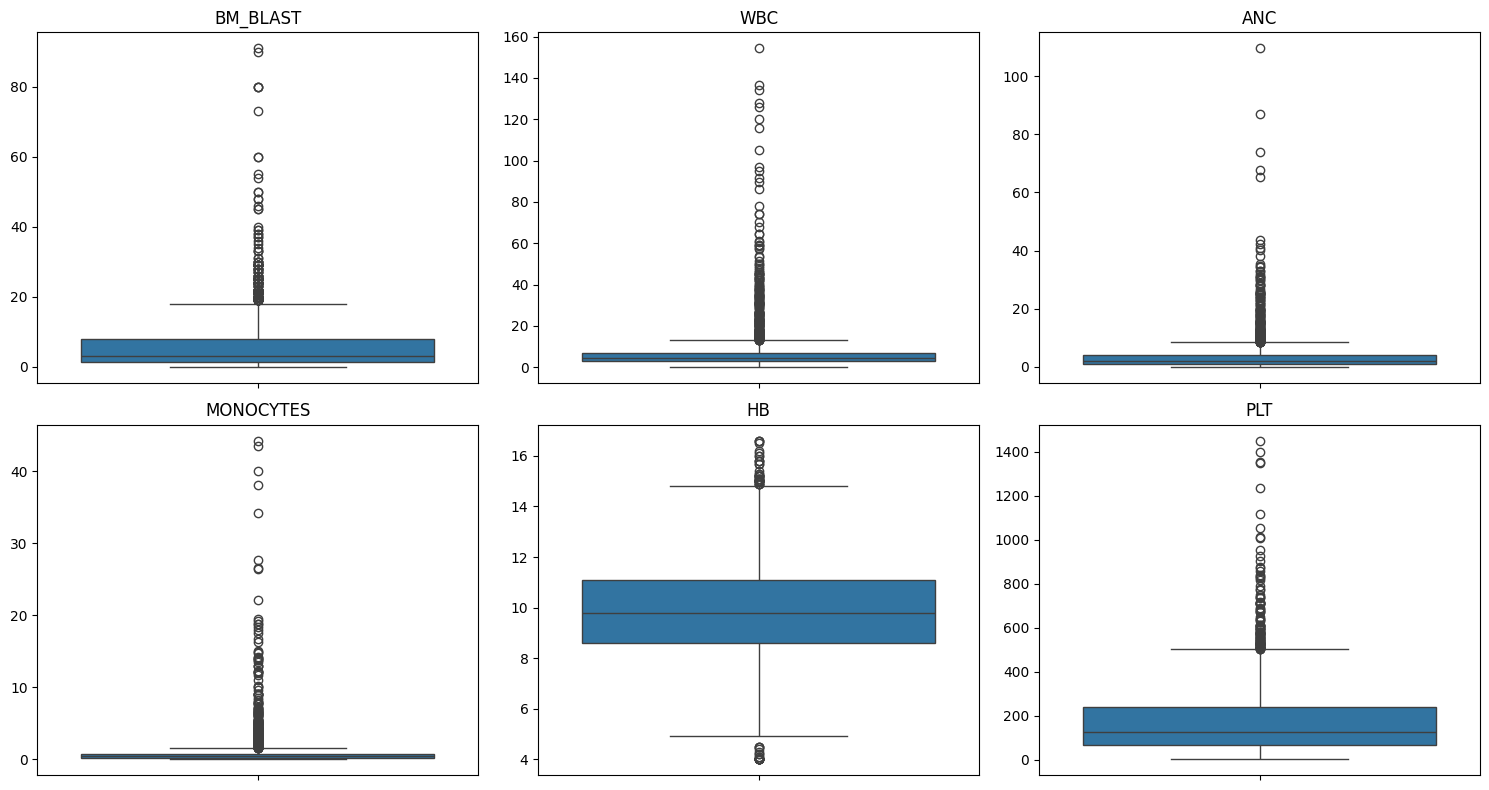

In [151]:
cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3

plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    
    plt.subplot(row,col,index + 1)
    plt.title(cl)
    sns.boxplot(df[cl])

plt.tight_layout()
plt.show()  

In [152]:
# Clinical Data

cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3


plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    q1 = df.select(pl.col(cl).quantile(0.25)).item()
    q3 = df.select(pl.col(cl).quantile(0.75)).item()
    
    iqr = q3 - q1
    
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df.filter(
        (pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound)
    )
    

    # Winsorisation : caper les valeurs extrêmes
    df = df.with_columns(
        pl.when(pl.col(cl) < lower_bound).then(lower_bound)
        .when(pl.col(cl) > upper_bound).then(upper_bound)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    
    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")


Number of outliers in column : BM_BLAST is : 181
Number of outliers in column : WBC is : 218
Number of outliers in column : ANC is : 192
Number of outliers in column : MONOCYTES is : 337
Number of outliers in column : HB is : 58
Number of outliers in column : PLT is : 110


<Figure size 1500x800 with 0 Axes>

In [153]:
df["CENTER"].value_counts()

CENTER,count
str,u32
"""UMG""",26
"""DUTH""",66
"""UOB""",88
"""ROM""",104
"""VU""",33
…,…
"""CCH""",159
"""CGM""",107
"""PV""",316


In [154]:


cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

for cl in cl_quantitative_var:
    mean = df.select(pl.col(cl).mean()).item()
    std = df.select(pl.col(cl).std()).item()

    z_scores = df.select(((pl.col(cl) - mean) / std).alias("z"))

    # On ajoute les Z-scores temporairement au DataFrame
    df_with_z = df.with_columns(((pl.col(cl) - mean) / std).alias(f"z_{cl}"))

    # Filtrer les outliers : abs(Z) > 3
    outliers = df_with_z.filter(pl.col(f"z_{cl}").abs() > 3)
    
    
    # Median
    median_val = df.select(pl.col(cl).median()).item()

    df = df.with_columns(
        pl.when((pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound))
        .then(median_val)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    # # Winsorisation : caper les valeurs extrêmes
    # df = df.with_columns(
    #     pl.when(pl.col(cl) < lower_bound).then(lower_bound)
    #     .when(pl.col(cl) > upper_bound).then(upper_bound)
    #     .otherwise(pl.col(cl))
    #     .alias(cl)
    # )

    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")

Number of outliers in column : BM_BLAST is : 0
Number of outliers in column : WBC is : 0
Number of outliers in column : ANC is : 0
Number of outliers in column : MONOCYTES is : 0
Number of outliers in column : HB is : 0
Number of outliers in column : PLT is : 0


# ENCODING

In [155]:
df["CENTER"].value_counts() # Catecorigal => Nominal , without any order

CENTER,count
str,u32
"""FLO""",68
"""MSK""",37
"""TUD""",73
"""MUV""",83
"""IHBT""",33
…,…
"""PV""",316
"""ROM""",104
"""ICO""",71


In [156]:
import category_encoders as ce

df_pd = df.to_pandas()

encoder = ce.BinaryEncoder(cols=["CENTER"])
df_encoded = encoder.fit_transform(df_pd)

df = pl.from_pandas(df_encoded)

df

# On encode avec le binary encoder car il n'intorduit pas d'ordre artificiel + n'explose pas le nombre de colonne + correct pour bcp de categories !

ID,CENTER_0,CENTER_1,CENTER_2,CENTER_3,CENTER_4,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str
"""P132697""",0,0,0,0,1,14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…"
"""P132698""",0,0,0,0,1,1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx"""
"""P116889""",0,0,0,0,1,15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…"
"""P132699""",0,0,0,0,1,1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…"
"""P132700""",0,0,0,0,1,6.0,13.175,8.425,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",1,0,1,1,1,1.0,3.7,2.53,0.53,8.9,499.0,"""46,xy[20]"""
"""P121829""",1,0,1,1,1,0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…"
"""P121830""",1,0,1,1,1,0.0,1.8,0.55,0.29,9.4,86.0,"""46,xy,del(20)(q11.2q13.1)[4]/4…"


# TRAITEMENT DE MOLECULAR DATA SET


In [197]:
mol_df

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
str,str,f64,f64,str,str,str,str,str,f64,f64
"""P100000""","""11""",1.19149248e8,1.19149248e8,"""G""","""A""","""CBL""","""p.C419Y""","""non_synonymous_codon""",0.083,1308.0
"""P100000""","""5""",1.31822301e8,1.31822301e8,"""G""","""T""","""IRF1""","""p.Y164*""","""stop_gained""",0.022,532.0
"""P100000""","""3""",7.769406e7,7.769406e7,"""G""","""C""","""ROBO2""","""p.?""","""splice_site_variant""",0.41,876.0
"""P100000""","""4""",1.06164917e8,1.06164917e8,"""G""","""T""","""TET2""","""p.R1262L""","""non_synonymous_codon""",0.43,826.0
"""P100000""","""2""",2.5468147e7,2.5468163e7,"""ACGAAGAGGGGGTGTTC""","""A""","""DNMT3A""","""p.E505fs*141""","""frameshift_variant""",0.0898,942.0
…,…,…,…,…,…,…,…,…,…,…
"""P131472""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null
"""P131505""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null
"""P131816""",null,null,null,null,null,"""MLL""","""MLL_PTD""","""PTD""",null,null


In [198]:
quant_vars = ["VAF" , "DEPTH"]
sub_df = mol_df.select(quant_vars)

# Conver to pandas
sub_pd = sub_df.to_pandas()

# Apply Model-Based Imputation (Random Forest)
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=42)
imputed_data = imputer.fit_transform(sub_pd)

# 4. To Polars
imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

# 5. Replace nulls
mol_df = mol_df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [200]:
mol_df["CHR"].value_counts().to_numpy()


array([['20', 999],
       ['1', 365],
       ['10', 18],
       ['18', 128],
       ['8', 41],
       ['5', 369],
       ['16', 91],
       ['12', 596],
       ['22', 55],
       [None, 114],
       ['6', 3],
       ['X', 1204],
       ['7', 537],
       ['11', 326],
       ['3', 115],
       ['2', 1513],
       ['21', 866],
       ['4', 1699],
       ['15', 192],
       ['17', 1387],
       ['14', 4],
       ['13', 42],
       ['19', 155],
       ['9', 116]], dtype=object)

In [ ]:
def to_int(str):
    if(str == 'X'):
        return 23 # A justifier ?
    else:
        return int(str)

mol_df = mol_df.with_columns(
    pl.col("CHR").map_elements(to_int , return_dtype=pl.Int64)
    .alias("CHR")
)

In [202]:
mol_df["CHR"].value_counts()

CHR,count
i64,u32
7,537
3,115
12,596
20,999
4,1699
…,…
13,42
22,55
6,3


# Ordinal encoding DNA Sequence

In [ ]:
def dna_to_array(dna):
    lst = []
    
    nitrogen_bases = ['a','g','t','c']
    dna = dna.lower()
    
    
    for ch in dna:
        if(ch in nitrogen_bases):
            lst.append(ch)
        else:
            lst.append('n')
        
        
    return lst

def ordinal_encoder_dna(dna):
    mapping = {'a' : 0.25 , 'c' : 0.5 ,'g':0.75 , 't' : 1.00}
    
    nitrogen_bases = ['a','g','t','c']
    
    return [mapping[x] for x in dna if x in nitrogen_bases else 0.00]

    


print(dna_to_array("ACTGGACCAAUU"))





['a', 'c', 't', 'g', 'g', 'a', 'c', 'c', 'a', 'a', 'n', 'n']


In [221]:


mol_df = mol_df.with_columns(
    pl.when(pl.col("REF").str.len_chars() <= 3)
      .then(pl.col("REF"))
      .otherwise(None)
      .alias("REF_size_3")
)


In [223]:
df_pd = mol_df.to_pandas()

encoder = ce.BinaryEncoder(cols=["REF_size_3"])
df_encoded = encoder.fit_transform(df_pd)

mol_df = pl.from_pandas(df_encoded)

In [250]:
mol_df["ALT"].unique().to_numpy()

array(['G', 'GAGAT', 'AGCAGAGCC', 'TGACA', 'GATTGAATATGAACACAGAGCACC',
       'GCCCC', 'GTTAC', 'ATTT', 'CGGGG', 'GAGAGGGGACTT', 'CATACTG',
       'GCTGC', 'ATTAAGGTGGAACCTGGCTT',
       'AATGTACATCATGTAGGGAAATTGCCTCCTTATCCCAC', 'ACGGGGCT', 'TTGAAA',
       'TTAAAG', 'CGT', 'CGTCT', 'GCTTC', 'GTCTCCTT', 'GA', 'GCCGGCCTA',
       'TC', 'AT', 'TGG', 'GCCGGT', 'CTG', 'CTGATGAAGATGATGCATATCAGG',
       'CGCTG', 'GCGGC', 'CGTACCTCTTCCACTT', 'CGACCGTACAA',
       'CGAAAAGAAGCCCCGGCTTG', 'TTTA', 'CA', 'TGTGA', 'TG', 'CTT',
       'TCATC', 'CGG', 'CTTCT', 'TTA', 'TGCGG', 'GGGTC', 'TGCCGC',
       'GCCCT', 'C', 'CTATT', 'GTAACC', 'CCGAG', 'GGTGA', 'CTTCA',
       'ATTGTC', 'TAC', 'CTCTG', 'ACCTTTCCC', 'GGAGC', 'ACCT', 'TGA',
       'ATCTC', 'TAGG', 'ACC', 'TT', 'TACCTC', 'TATTGAAGATGTCC', 'GAA',
       'AGGCCTT', 'CACTTGAAGAAAATTGCGCTAAAGCCCTG',
       'ATGAACCCTTACCCTGGGCTTTTGAATCAGAATACCCAATATCCATCATATCAATGCAATGGAAACCTATC',
       'CCCCTAGTGTTGGTCGGCGTCCACACTCTGAGGACAGTGACCTCTCTGCTCTGTCCCTCA'

In [225]:
mol_df = mol_df.with_columns(
    pl.when(pl.col("REF").str.len_chars() > 3)
      .then(pl.col("REF"))
      .otherwise(None)
      .alias("REF_k_mer")
)

In [227]:
mol_df["REF_k_mer"].value_counts()

REF_k_mer,count
str,u32
"""TTCTCA""",1
"""AAAAGT""",1
"""GCGGGGCCCGCGCCC""",1
"""CACCAGCGGCCGCAGCGCCGGCGCCCCGA""",1
"""CGGATGTTAGAACTGAAT""",1
…,…
"""GAAAAGTGCTAATTACCATGACAAGAACAT…",1
"""GAAGT""",1
"""AGTTTTCA""",1


In [236]:
def extract_kmers(sequence, k):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

mol_df = mol_df.with_columns(
    pl.col("REF_k_mer").map_elements(lambda x: extract_kmers(x, 3))
    .alias("REF_3_mer_lst")
)


C:\Users\zakar\AppData\Local\Temp\ipykernel_17016\2746174522.py:4: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  mol_df = mol_df.with_columns(


In [238]:
mol_df = mol_df.with_columns(
    pl.col("REF_k_mer").map_elements(lambda x: extract_kmers(x, 4))
    .alias("REF_4_mer_lst")
)

C:\Users\zakar\AppData\Local\Temp\ipykernel_17016\3407547938.py:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  mol_df = mol_df.with_columns(


In [242]:
mol_df["ALT"].unique()

ALT
str
"""AGT"""
"""CGACCG"""
"""GGTGA"""
"""AAGAAATGG"""
"""TGCGA"""
…
"""CCTTT"""
"""GCCCT"""
"""CCACAG"""


In [ ]:
ref = mol_df["REF"].unique().to_numpy()

cpt = 0 




for (index , elem) in enumerate(ref):
    if((elem is not None) and len(elem) <=3):
        print(elem)
        cpt+=1
        
        
print(cpt)

import category_encoders as ce

df_pd = mol_df.to_pandas()

encoder = ce.BinaryEncoder(cols=["REF"])
df_encoded = encoder.fit_transform(df_pd)

df = pl.from_pandas(df_encoded)

df

G
C
A
AGG
AGC
TAG
CTG
GAA
CCG
GAT
GT
CTA
GTT
CG
GAC
GGT
TAA
TAC
AAC
ACT
TGG
TGA
CCA
AAG
TCA
GCC
CAT
GTC
TC
CA
CAA
TAT
AGT
TG
TA
CT
CTT
CCT
AC
CAG
AG
CC
TTA
TGC
ATG
TTC
GGA
AAT
GC
ATT
TTG
T
GCT
GA
AT
GG
TCG
GCA
58


In [174]:
mol_df["REF"].value_counts()


REF,count
str,u32
"""TTG""",3
"""TCGGGCTGC""",1
"""GGCAGC""",1
"""AGGTCT""",1
"""ACGCG""",1
…,…
"""GAATCCCAATAGGAATCACCCCACC""",1
"""CTGTG""",1
"""TTCGTGTTATA""",1


In [175]:
mol_df["ALT"].value_counts()

ALT,count
str,u32
"""GTC""",6
"""TCGATGC""",1
"""CAGTA""",1
"""CGG""",2
"""CTGATGAAGATGATGCATATCAGG""",1
…,…
"""GCTAT""",1
"""TGAAATAGAAAATATGATGAATGCAATATT…",1
"""TCAAA""",1
